## Test notebook create a MRIQC agent 
- The agent will query https://mriqc.nimh.nih.gov/ API and compare mriqc IQMs


#### Usage Notes


    1.Sampling the distribution of IQMs and imaging parameters across datasets (including both publicly available and private), and across scanning sites.
    2.Training machines and humans.

These potential usages are revised with finer detail in the following. Note this resource is focused on quality control (QC), rather than quality assessment (QA). While QC focuses on flagging images that may endanger downstream analysis for their bad quality (i.e., identifying outliers), QA identifies issues that degrade all image’s quality (i.e., improving the overall quality of images after a problem spotted in the scanning device or acquisition protocol -via QC of actual images- is fixed).
Collecting IQMs and imaging parameters

Based on this information, researchers can explore questions such as the relationship of particular imaging parameters (e.g. MR scan vendor, or more interestingly, the multi-band acceleration factor of newest functional MRI sequences) with respect to the signal-to-noise ratio or the power of N/2 aliasing ghosts. Jupyter notebooks demonstrating examples of this use-case are available at https://www.kaggle.com/chrisfilo/mriqc/kernels.

In [4]:
# Example: load a sample MRIQC IQM JSON and run the artifact detector
import json
from pathlib import Path
from mriqc_utils import detect_image_artifacts

iqm_path = Path('../sample_data/derivatives/mriqc/sub-ED01/ses-01/anat/sub-ED01_ses-01_run-1_T1w.json')
if not iqm_path.exists():
    raise FileNotFoundError(f'MRIQC JSON not found: {iqm_path}')

with iqm_path.open('r') as f:
    iqm = json.load(f)

# detect artifacts using conservative defaults for T1-weighted images
report = detect_image_artifacts(iqm, modality='T1w')

print('Detected flags:', report['flags'])
print('Observed scores:')
for k, v in report['scores'].items():
    print(f'  {k}: {v}')

print('Explanations:')
for k, v in report['explanations'].items():
    print(f'  {k}: {v}')

Detected flags: ['high_cjv', 'high_efc', 'low_snr']
Observed scores:
  snr: 5.4696761129313005
  cjv: 0.6677331455584082
  efc: 0.5271859407022896
  fwhm: 4.50116
Explanations:
  low_snr: snr=5.4696761129313005 < 20.0
  high_cjv: cjv=0.6677331455584082 > 0.5
  high_efc: efc=0.5271859407022896 > 0.35


In [5]:
import requests

BASE = "https://mriqc.nimh.nih.gov/api/v1"

where = (
    'bids_meta.Manufacturer=="Siemens" and '
    'bids_meta.MagneticFieldStrength==3'
    # add model name once you confirm the key exists in step 1, e.g.:
    # ' and bids_meta.ManufacturersModelName=="Prisma"'
)

params = {
    "where": where,
    "max_results": 1000,   # API often allows up to 1000 per page
    "page": 1
}

r = requests.get(f"{BASE}/T1w", params=params, timeout=60)
r.raise_for_status()
data = r.json()
print("Returned:", len(data["_items"]), "records; total:", data["_meta"].get("total"))

import json
with open("test.json", "w") as f:
    json.dump(data, f, indent=4)

Returned: 50 records; total: None


In [7]:
snr_list = []
for itm in data["_items"]:
    snr = itm["snr_total"]
    snr_list.append(snr)

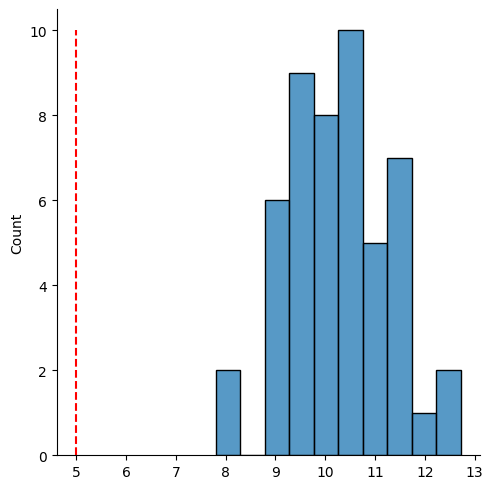

In [16]:
# plot iqm dist against the sample 
import seaborn as sns 
import matplotlib.pyplot as plt
sns.displot(snr_list, bins=10)


plt.vlines(x=5, ymin=0, ymax=10, color='r', linestyle='--')